# **FASE 2 - Modelos y evaluación**

In [1]:
# ==========================================
# 1. LIBRERÍAS
# ==========================================

import time
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    IsolationForest
)

from xgboost import XGBClassifier

from sklearn.metrics import (

    confusion_matrix,

    accuracy_score,

    balanced_accuracy_score,

    precision_score,

    recall_score,

    f1_score,

    average_precision_score
)

In [2]:
# ==========================================
# 2. MONTAJE DRIVE
# ==========================================

from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# ==========================================
# 3. CARGA DATASETS .csv
# ==========================================

RUTA_DATASETS = (
    "/content/drive/MyDrive/TFM/"
    "Datasets_Ventanas_V2"
)

VENTANAS_ESTUDIO = [
    1,
    2,
    5,
    10,
    30
]

datasets = {}

for ventana in VENTANAS_ESTUDIO:

    ruta = (
        f"{RUTA_DATASETS}/"
        f"dataset_{ventana}s.csv"
    )

    datasets[ventana] = pd.read_csv(
        ruta
    )

    print(
        f"Ventana {ventana}s: "
        f"{datasets[ventana].shape}"
    )

Ventana 1s: (516249, 20)
Ventana 2s: (266912, 20)
Ventana 5s: (114497, 20)
Ventana 10s: (59762, 20)
Ventana 30s: (21247, 20)


In [4]:
# ==========================================
# 4. DIVISIÓN TEMPORAL POR ESCENARIO
# ==========================================

def division_temporal_por_escenario(
        df,
        porcentaje_train=0.7):

    trains = []
    tests = []

    for escenario in df["escenario"].unique():

        tmp = (

            df[
                df["escenario"] == escenario
            ]

            .sort_values(
                "tiempo_inicio"
            )

            .reset_index(
                drop=True
            )

        )

        corte = int(
            len(tmp)
            *
            porcentaje_train
        )

        trains.append(
            tmp.iloc[:corte]
        )

        tests.append(
            tmp.iloc[corte:]
        )

    train_df = pd.concat(
        trains,
        ignore_index=True
    )

    test_df = pd.concat(
        tests,
        ignore_index=True
    )

    return train_df, test_df

In [5]:
# ==========================================
# 5. EXCLUSIÓN DE COLUMNAS
# ==========================================

COLUMNAS_EXCLUIDAS = [

    "ventana_id",

    "tiempo_inicio",
    "tiempo_fin",

    "escenario",
    "tipo_escenario",

    "ventana_global",

    "label_binaria",

    "primer_ts_malicioso_ventana",

    "inicio_real_ataque_escenario"

]

In [6]:
# ==========================================
# 6. MÉTRICAS IDS
# ==========================================

def calcular_metricas_ids(
    y_true,
    y_pred
):

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred
    ).ravel()

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    balanced_acc = (
        balanced_accuracy_score(
            y_true,
            y_pred
        )
    )

    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )

    specificity = (
        tn / (tn + fp)
    )

    fpr = (
        fp / (fp + tn)
    )

    return {

        "Accuracy":
        accuracy,

        "Balanced Accuracy":
        balanced_acc,

        "Precision":
        precision,

        "Recall":
        recall,

        "F1":
        f1,

        "Specificity":
        specificity,

        "FPR":
        fpr
    }

In [7]:
# ==========================================
# 7. MODELOS
# ==========================================

modelos = {

    "Logistic Regression":

        LogisticRegression(
            max_iter=1000,
            class_weight="balanced"
        ),

    "Decision Tree":

        DecisionTreeClassifier(
            class_weight="balanced",
            random_state=42
        ),

    "Random Forest":

        RandomForestClassifier(
            n_estimators=100,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ),

    "XGBoost":

        XGBClassifier(
            n_estimators=100,
            max_depth=6,
            random_state=42,
            eval_metric="logloss"
        )

}

In [8]:
# ==========================================
# 8. ENTRENAMIENTO DE MODELOS SUPERVISADOS
# ==========================================

resultados = []

predicciones_guardadas = {}

for ventana, df in datasets.items():

    print("\n" + "="*60)
    print(f"VENTANA {ventana}s")
    print("="*60)

    train_df, test_df = (
        division_temporal_por_escenario(df)
    )

    X_train = train_df.drop(
        columns=COLUMNAS_EXCLUIDAS
    )

    X_test = test_df.drop(
        columns=COLUMNAS_EXCLUIDAS
    )

    y_train = train_df[
        "label_binaria"
    ]

    y_test = test_df[
        "label_binaria"
    ]

    scaler = StandardScaler()

    X_train = scaler.fit_transform(
        X_train
    )

    X_test = scaler.transform(
        X_test
    )

    for nombre_modelo, modelo in modelos.items():

        print(
            f"Entrenando {nombre_modelo}"
        )

        inicio = time.time()

        modelo.fit(
            X_train,
            y_train
        )

        tiempo_train = (
            time.time()
            -
            inicio
        )

        inicio = time.time()

        y_pred = modelo.predict(
            X_test
        )

        tiempo_inferencia_total = (
            time.time()
            -
            inicio
        )

        tiempo_inferencia_ventana = (

            tiempo_inferencia_total

            /
            len(y_pred)

            *
            1000

        )

        metricas = (
            calcular_metricas_ids(
                y_test,
                y_pred
            )
        )

        try:

            scores = modelo.predict_proba(
                X_test
            )[:,1]

            pr_auc = (
                average_precision_score(
                    y_test,
                    scores
                )
            )

        except:

            pr_auc = np.nan

        fila = {

            "Ventana":
            ventana,

            "Modelo":
            nombre_modelo,

            "Train Time (s)":
            round(
                tiempo_train,
                4
            ),

            "Inference Total (s)":
            round(
                tiempo_inferencia_total,
                6
            ),

            "Inference per Window (ms)":
            round(
                tiempo_inferencia_ventana,
                6
            ),

            "PR-AUC":
            pr_auc

        }

        fila.update(
            metricas
        )

        resultados.append(
            fila
        )

        predicciones_guardadas[
            (
                ventana,
                nombre_modelo
            )
        ] = (

            y_test,
            y_pred

        )


VENTANA 1s
Entrenando Logistic Regression
Entrenando Decision Tree
Entrenando Random Forest
Entrenando XGBoost

VENTANA 2s
Entrenando Logistic Regression
Entrenando Decision Tree
Entrenando Random Forest
Entrenando XGBoost

VENTANA 5s
Entrenando Logistic Regression
Entrenando Decision Tree
Entrenando Random Forest
Entrenando XGBoost

VENTANA 10s
Entrenando Logistic Regression
Entrenando Decision Tree
Entrenando Random Forest
Entrenando XGBoost

VENTANA 30s
Entrenando Logistic Regression
Entrenando Decision Tree
Entrenando Random Forest
Entrenando XGBoost


In [9]:
# ==========================================
# 9. ENTRENAMIENTO DE MODELO NO SUPERVISADO (IF)
# ==========================================

for ventana, df in datasets.items():

    print("\n" + "="*60)
    print(
        f"Isolation Forest - {ventana}s"
    )

    train_df, test_df = (
        division_temporal_por_escenario(df)
    )

    train_benigno = (

        train_df[
            train_df[
                "label_binaria"
            ] == 0
        ]

    )

    if len(train_benigno) == 0:

        continue

    X_train = train_benigno.drop(
        columns=COLUMNAS_EXCLUIDAS
    )

    X_test = test_df.drop(
        columns=COLUMNAS_EXCLUIDAS
    )

    y_test = test_df[
        "label_binaria"
    ]

    scaler = StandardScaler()

    X_train = scaler.fit_transform(
        X_train
    )

    X_test = scaler.transform(
        X_test
    )

    modelo = IsolationForest(
        contamination=0.01,
        random_state=42
    )

    inicio = time.time()

    modelo.fit(X_train)

    tiempo_train = (
        time.time()
        -
        inicio
    )

    inicio = time.time()

    pred = modelo.predict(
        X_test
    )

    tiempo_inf = (
        time.time()
        -
        inicio
    )

    y_pred = np.where(
        pred == -1,
        1,
        0
    )

    tiempo_inf_ventana = (

        tiempo_inf

        /
        len(y_pred)

        *
        1000

    )

    metricas = (
        calcular_metricas_ids(
            y_test,
            y_pred
        )
    )

    fila = {

        "Ventana":
        ventana,

        "Modelo":
        "Isolation Forest",

        "Train Time (s)":
        round(
            tiempo_train,
            4
        ),

        "Inference Total (s)":
        round(
            tiempo_inf,
            6
        ),

        "Inference per Window (ms)":
        round(
            tiempo_inf_ventana,
            6
        ),

        "PR-AUC":
        np.nan
    }

    fila.update(
        metricas
    )

    resultados.append(
        fila
    )


Isolation Forest - 1s

Isolation Forest - 2s

Isolation Forest - 5s

Isolation Forest - 10s

Isolation Forest - 30s


In [10]:
# ==========================================
# 10. RESULTADOS
# ==========================================

df_resultados = pd.DataFrame(
    resultados
)

df_resultados = (
    df_resultados
    .sort_values(
        [
            "Ventana",
            "Balanced Accuracy"
        ],
        ascending=[
            True,
            False
        ]
    )
)

df_resultados

,Ventana,Modelo,Train Time (s),Inference Total (s),Inference per Window (ms),PR-AUC,Accuracy,Balanced Accuracy,Precision,Recall,F1,Specificity,FPR
3,1,XGBoost,3.0508,0.296681,0.001916,0.986496,0.953680,0.892879,0.964470,0.981264,0.972795,0.804494,0.195506
2,1,Random Forest,34.8472,1.529098,0.009873,0.985002,0.949238,0.891293,0.964721,0.975526,0.970094,0.807059,0.192941
1,1,Decision Tree,1.7523,0.021549,0.000139,0.984519,0.946035,0.889867,0.964786,0.971517,0.968140,0.808217,0.191783
0,1,Logistic Regression,8.8780,0.009278,0.000060,0.984099,0.930139,0.878106,0.963118,0.953745,0.958409,0.802466,0.197534
20,1,Isolation Forest,1.7516,2.179137,0.014070,NaN,0.180496,0.511535,0.957699,0.030311,0.058762,0.992759,0.007241
6,2,Random Forest,13.8607,0.372004,0.004646,0.996859,0.900485,0.915249,0.996223,0.898937,0.945083,0.931561,0.068439
5,2,Decision Tree,0.5399,0.008415,0.000105,0.996422,0.889258,0.911857,0.996465,0.886889,0.938489,0.936825,0.063175
4,2,Logistic Regression,2.0710,0.006894,0.000086,0.996995,0.855841,0.906947,0.997862,0.850483,0.918297,0.963411,0.036589
7,2,XGBoost,1.4878,0.159007,0.001986,0.998303,0.985651,0.867785,0.987073,0.998007,0.992510,0.737563,0.262437
21,2,Isolation Forest,0.3945,0.793120,0.009904,NaN,0.047579,0.498696,0.666667,0.000288,0.000577,0.997105,0.002895


In [11]:
# ==========================================
# 11. TOP MODELOS
# ==========================================

df_resultados.sort_values(
    ["Balanced Accuracy", "Train Time (s)"],
    ascending=[False, True]
)

,Ventana,Modelo,Train Time (s),Inference Total (s),Inference per Window (ms),PR-AUC,Accuracy,Balanced Accuracy,Precision,Recall,F1,Specificity,FPR
18,30,Random Forest,0.6596,0.044633,0.006999,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
19,30,XGBoost,0.1332,0.009060,0.001421,1.000000,0.999530,0.998507,0.999647,0.999823,0.999735,0.997191,0.002809
17,30,Decision Tree,0.1131,0.001000,0.000157,0.999118,0.999216,0.996489,0.999118,1.000000,0.999559,0.992978,0.007022
14,10,Random Forest,1.4240,0.046439,0.002590,0.999890,0.989906,0.991662,0.999643,0.989700,0.994647,0.993624,0.006376
15,10,XGBoost,0.3382,0.031579,0.001761,0.999914,0.989851,0.991131,0.999584,0.989700,0.994618,0.992561,0.007439
13,10,Decision Tree,0.1117,0.001679,0.000094,0.999072,0.989237,0.987294,0.999168,0.989465,0.994293,0.985122,0.014878
10,5,Random Forest,4.4618,0.158863,0.004624,0.999652,0.957558,0.973966,0.999718,0.956488,0.977625,0.991445,0.008555
9,5,Decision Tree,0.1772,0.001870,0.000054,0.999348,0.957413,0.972050,0.999592,0.956458,0.977549,0.987643,0.012357
8,5,Logistic Regression,1.0283,0.001337,0.000039,0.999134,0.900416,0.946334,0.999833,0.897420,0.945863,0.995247,0.004753
12,10,Logistic Regression,0.2681,0.000819,0.000046,0.998578,0.885791,0.939733,1.000000,0.879466,0.935868,1.000000,0.000000


In [12]:
# ==========================================
# 11.1 TOP RESULTADOS
# ==========================================

df_resultados[
    [

        "Ventana",

        "Modelo",

        "Balanced Accuracy",

        "F1",

        "PR-AUC",

        "Train Time (s)",

        "Inference per Window (ms)"

    ]

].sort_values(

    ["Balanced Accuracy",
     "Train Time (s)"],

    ascending=[False, True]

)

,Ventana,Modelo,Balanced Accuracy,F1,PR-AUC,Train Time (s),Inference per Window (ms)
18,30,Random Forest,1.000000,1.000000,1.000000,0.6596,0.006999
19,30,XGBoost,0.998507,0.999735,1.000000,0.1332,0.001421
17,30,Decision Tree,0.996489,0.999559,0.999118,0.1131,0.000157
14,10,Random Forest,0.991662,0.994647,0.999890,1.4240,0.002590
15,10,XGBoost,0.991131,0.994618,0.999914,0.3382,0.001761
13,10,Decision Tree,0.987294,0.994293,0.999072,0.1117,0.000094
10,5,Random Forest,0.973966,0.977625,0.999652,4.4618,0.004624
9,5,Decision Tree,0.972050,0.977549,0.999348,0.1772,0.000054
8,5,Logistic Regression,0.946334,0.945863,0.999134,1.0283,0.000039
12,10,Logistic Regression,0.939733,0.935868,0.998578,0.2681,0.000046



MODELO: Decision Tree


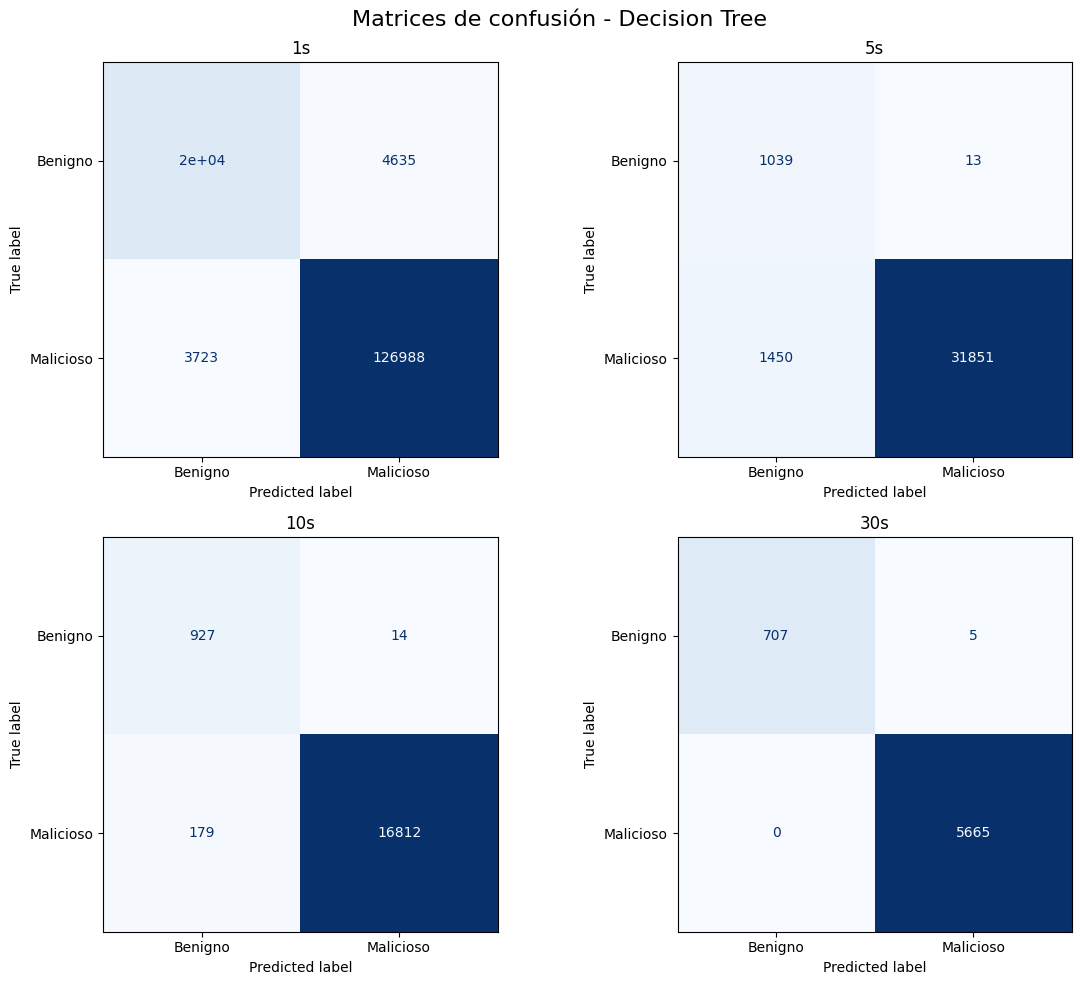


MODELO: Random Forest


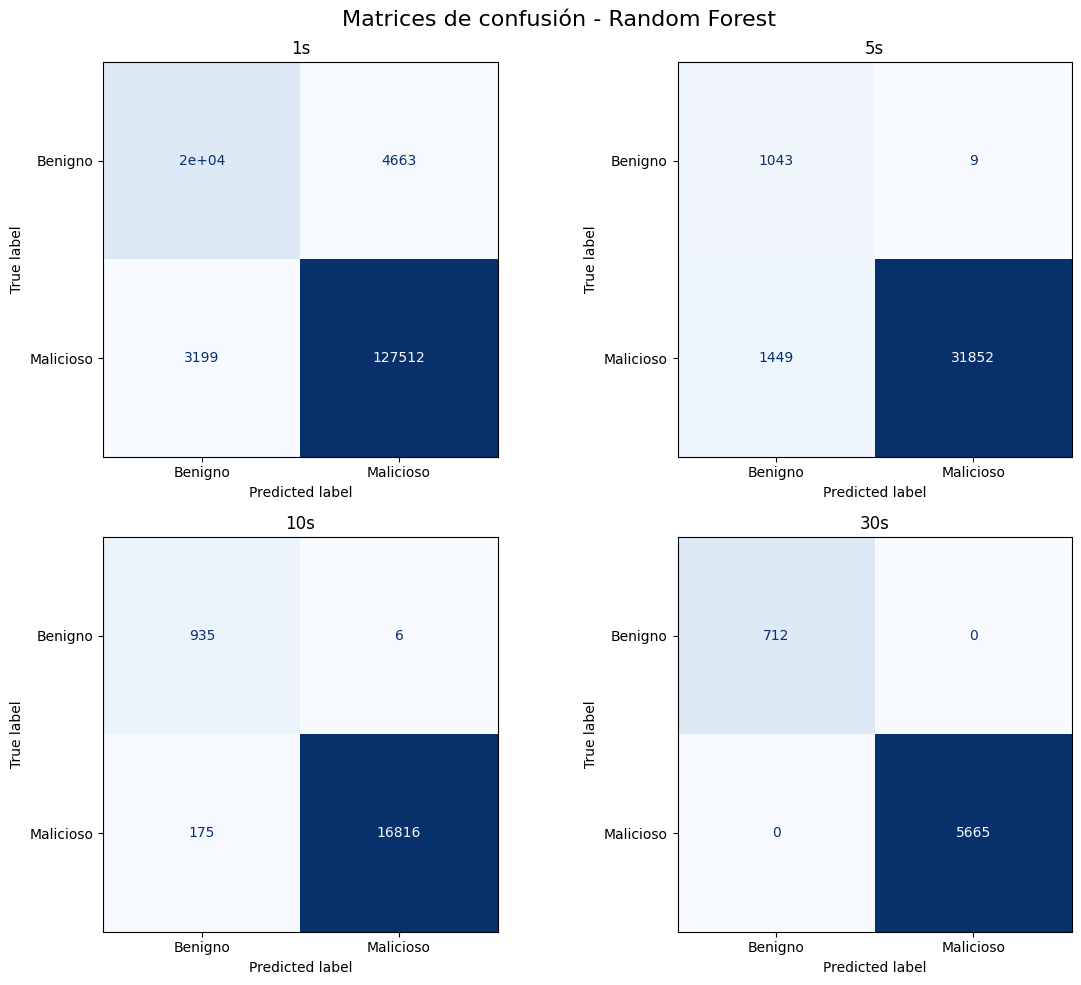


MODELO: XGBoost


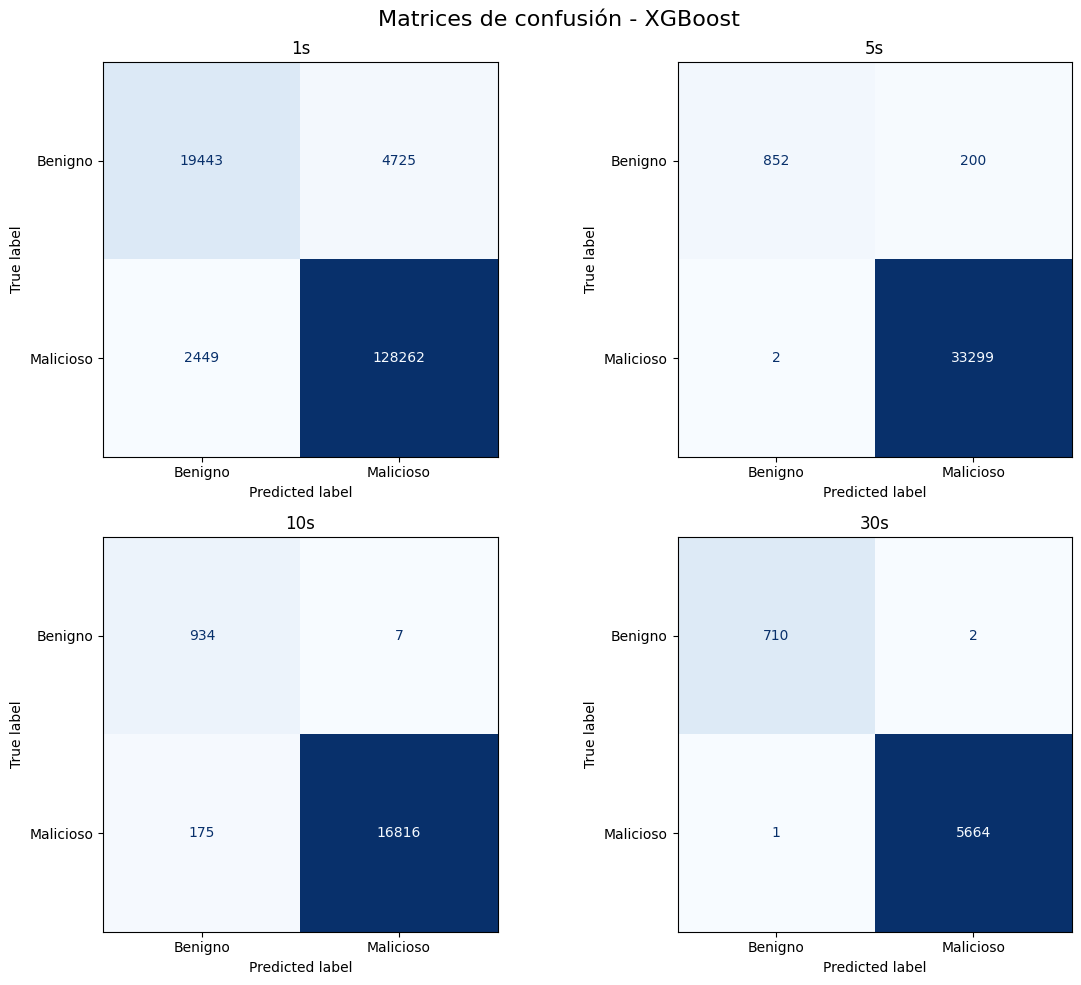

In [13]:
# ==========================================
# 12. MATRIZ DE CONFUSIÓN
# ==========================================

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

MODELOS_MATRIZ = [

    "Decision Tree",
    "Random Forest",
    "XGBoost"

]

VENTANAS_MATRIZ = [

    1,
    5,
    10,
    30

]

for modelo in MODELOS_MATRIZ:

    print("\n" + "="*80)
    print(f"MODELO: {modelo}")
    print("="*80)

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(12, 10)
    )

    axes = axes.flatten()

    for idx, ventana in enumerate(
        VENTANAS_MATRIZ
    ):

        y_test, y_pred = (

            predicciones_guardadas[
                (
                    ventana,
                    modelo
                )
            ]

        )

        cm = confusion_matrix(
            y_test,
            y_pred
        )

        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=[
                "Benigno",
                "Malicioso"
            ]
        )

        disp.plot(
            cmap="Blues",
            ax=axes[idx],
            colorbar=False
        )

        axes[idx].set_title(
            f"{ventana}s"
        )

    plt.suptitle(
        f"Matrices de confusión - {modelo}",
        fontsize=16
    )

    plt.tight_layout()

    plt.show()

In [14]:
# ==========================================
# 13. ALMACENAMIENTO DE RESULTADOS
# ==========================================

# ------------------------------------------
# .csv
# ------------------------------------------

ruta_csv = (
    "/content/drive/MyDrive/TFM/"
    "resultados_modelos_v2.csv"
)

df_resultados.to_csv(
    ruta_csv,
    index=False
)

print(
    "✅ CSV guardado"
)

# ------------------------------------------
# excel
# ------------------------------------------

ruta_excel = (
    "/content/drive/MyDrive/TFM/"
    "resultados_modelos_v2.xlsx"
)

df_resultados.to_excel(
    ruta_excel,
    index=False
)

print(
    "✅ Excel guardado"
)

✅ CSV guardado
✅ Excel guardado


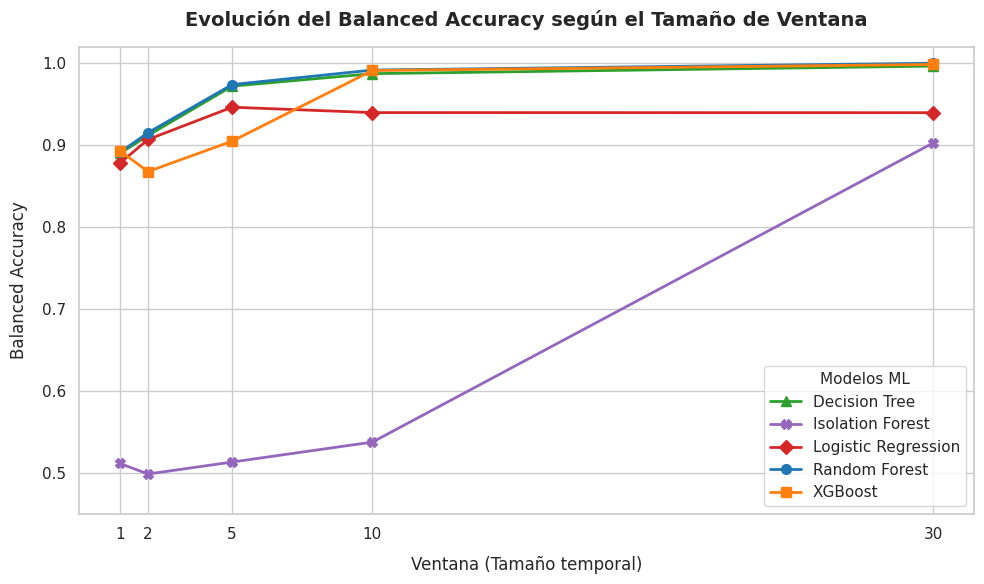

In [15]:
# ==========================================
# 14. BALANCED ACCURACY POR TAMAÑO DE VENTANA
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------
# Preparación de datos
# ------------------------------------------

df_grouped = (
    df_resultados
    .sort_values(["Modelo", "Ventana"])
)

# ------------------------------------------
# Estilo visual
# ------------------------------------------

plt.figure(figsize=(10, 6))

sns.set_theme(style="whitegrid")

palette = {
    "Random Forest": "#1f77b4",
    "XGBoost": "#ff7f0e",
    "Decision Tree": "#2ca02c",
    "Logistic Regression": "#d62728",
    "Isolation Forest": "#9467bd",
}

markers = {
    "Random Forest": "o",
    "XGBoost": "s",
    "Decision Tree": "^",
    "Logistic Regression": "D",
    "Isolation Forest": "X",
}

# ------------------------------------------
# Curvas
# ------------------------------------------

for modelo in df_grouped["Modelo"].unique():

    datos = df_grouped[
        df_grouped["Modelo"] == modelo
    ]

    plt.plot(
        datos["Ventana"],
        datos["Balanced Accuracy"],
        color=palette.get(modelo, "#333333"),
        marker=markers.get(modelo, "o"),
        linewidth=2,
        markersize=7,
        label=modelo,
    )

# ------------------------------------------
# Formato
# ------------------------------------------

plt.title(
    "Evolución del Balanced Accuracy según el Tamaño de Ventana",
    fontsize=14,
    fontweight="bold",
    pad=15,
)

plt.xlabel(
    "Ventana (Tamaño temporal)",
    fontsize=12,
    labelpad=10,
)

plt.ylabel(
    "Balanced Accuracy",
    fontsize=12,
    labelpad=10,
)

plt.xticks(
    sorted(df_grouped["Ventana"].unique())
)

plt.ylim(0.45, 1.02)

plt.legend(
    title="Modelos ML",
    title_fontsize=11,
    loc="lower right",
    frameon=True,
)

plt.tight_layout()

plt.savefig(
    "balanced_accuracy_vs_ventana.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

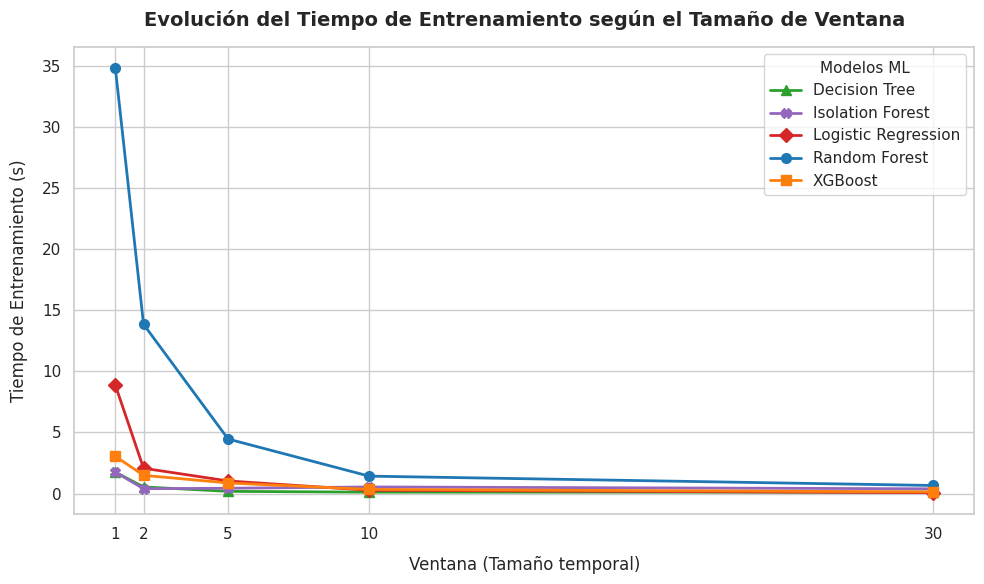

In [16]:
# ==========================================
# 15. TIEMPO DE ENTRENAMIENTO POR TAMAÑO DE VENTANA
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------
# Preparación de datos
# ------------------------------------------

df_grouped = (
    df_resultados
    .sort_values(["Modelo", "Ventana"])
)

# ------------------------------------------
# Estilo visual
# ------------------------------------------

plt.figure(figsize=(10, 6))

sns.set_theme(style="whitegrid")

palette = {
    "Random Forest": "#1f77b4",
    "XGBoost": "#ff7f0e",
    "Decision Tree": "#2ca02c",
    "Logistic Regression": "#d62728",
    "Isolation Forest": "#9467bd",
}

markers = {
    "Random Forest": "o",
    "XGBoost": "s",
    "Decision Tree": "^",
    "Logistic Regression": "D",
    "Isolation Forest": "X",
}

# ------------------------------------------
# Curvas
# ------------------------------------------

for modelo in df_grouped["Modelo"].unique():

    datos = df_grouped[
        df_grouped["Modelo"] == modelo
    ]

    plt.plot(
        datos["Ventana"],
        datos["Train Time (s)"],
        color=palette.get(modelo, "#333333"),
        marker=markers.get(modelo, "o"),
        linewidth=2,
        markersize=7,
        label=modelo,
    )

# ------------------------------------------
# Formato
# ------------------------------------------

plt.title(
    "Evolución del Tiempo de Entrenamiento según el Tamaño de Ventana",
    fontsize=14,
    fontweight="bold",
    pad=15,
)

plt.xlabel(
    "Ventana (Tamaño temporal)",
    fontsize=12,
    labelpad=10,
)

plt.ylabel(
    "Tiempo de Entrenamiento (s)",
    fontsize=12,
    labelpad=10,
)

plt.xticks(
    sorted(df_grouped["Ventana"].unique())
)

plt.legend(
    title="Modelos ML",
    title_fontsize=11,
    loc="upper right",
    frameon=True,
)

plt.tight_layout()

plt.savefig(
    "train_time_vs_ventana.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

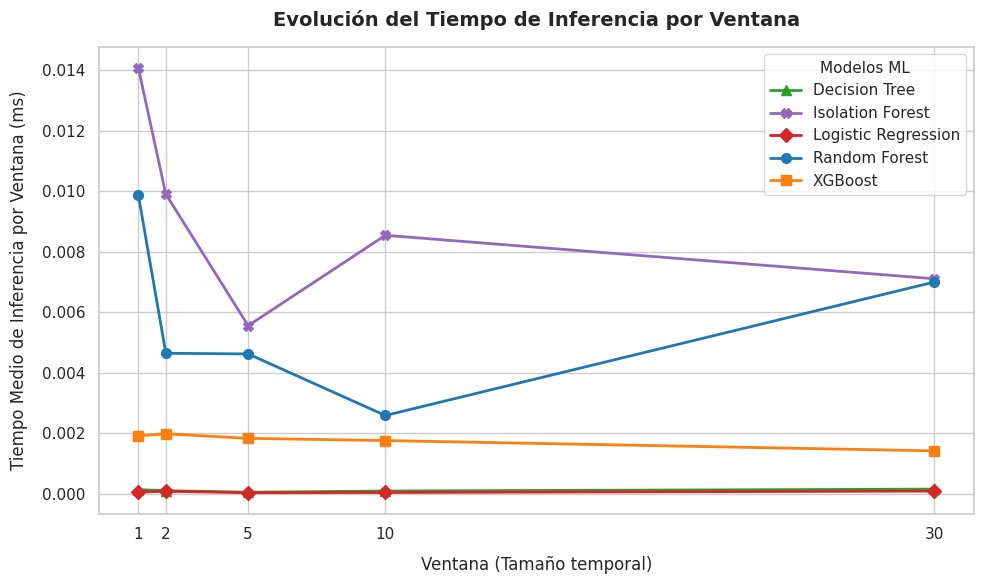

In [17]:
# ==========================================
# 16. TIEMPO DE INFERENCIA POR TAMAÑO DE VENTANA
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------
# Preparación de datos
# ------------------------------------------

df_grouped = (
    df_resultados
    .sort_values(["Modelo", "Ventana"])
)

# ------------------------------------------
# Estilo visual
# ------------------------------------------

plt.figure(figsize=(10, 6))

sns.set_theme(style="whitegrid")

palette = {
    "Random Forest": "#1f77b4",
    "XGBoost": "#ff7f0e",
    "Decision Tree": "#2ca02c",
    "Logistic Regression": "#d62728",
    "Isolation Forest": "#9467bd",
}

markers = {
    "Random Forest": "o",
    "XGBoost": "s",
    "Decision Tree": "^",
    "Logistic Regression": "D",
    "Isolation Forest": "X",
}

# ------------------------------------------
# Curvas
# ------------------------------------------

for modelo in df_grouped["Modelo"].unique():

    datos = df_grouped[
        df_grouped["Modelo"] == modelo
    ]

    plt.plot(
        datos["Ventana"],
        datos["Inference per Window (ms)"],
        color=palette.get(modelo, "#333333"),
        marker=markers.get(modelo, "o"),
        linewidth=2,
        markersize=7,
        label=modelo,
    )

# ------------------------------------------
# Formato
# ------------------------------------------

plt.title(
    "Evolución del Tiempo de Inferencia por Ventana",
    fontsize=14,
    fontweight="bold",
    pad=15,
)

plt.xlabel(
    "Ventana (Tamaño temporal)",
    fontsize=12,
    labelpad=10,
)

plt.ylabel(
    "Tiempo Medio de Inferencia por Ventana (ms)",
    fontsize=12,
    labelpad=10,
)

plt.xticks(
    sorted(df_grouped["Ventana"].unique())
)

plt.legend(
    title="Modelos ML",
    title_fontsize=11,
    loc="upper right",
    frameon=True,
)

plt.tight_layout()

plt.savefig(
    "inference_time_vs_ventana.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()